# 02 — Exploratory Data Analysis

## Objective

This notebook explores the relationship between daily climate conditions and streamflow for the Squamish River near Brackendale during 2020.

The main questions are:

1. How does streamflow vary throughout the year?
2. How do precipitation and temperature vary seasonally?
3. Is same-day precipitation strongly associated with streamflow?
4. Are there major high-flow events that are not explained by same-day rainfall?
5. What patterns should guide the feature-engineering stage?

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

df = pd.read_csv(
    ROOT / "data" / "processed" / "hydroclimate_merged.csv",
    parse_dates=["date"]
)

df.head()

,date,mean_temp_c,precipitation_mm,streamflow_cms
0,2020-01-01,5.8,13.0,135.0
1,2020-01-02,2.3,10.8,135.0
2,2020-01-03,4.1,15.0,131.0
3,2020-01-04,5.5,6.0,234.0
4,2020-01-05,3.2,3.2,140.0


## 1. Dataset Overview

In [2]:
print("Shape:")
print(df.shape)

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Shape:
(366, 4)

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00

Data types:
date                datetime64[us]
mean_temp_c                float64
precipitation_mm           float64
streamflow_cms             float64
dtype: object

Missing values:
date                0
mean_temp_c         4
precipitation_mm    9
streamflow_cms      0
dtype: int64


In [3]:
df.describe()

,date,mean_temp_c,precipitation_mm,streamflow_cms
count,366,362.000000,357.000000,366.000000
mean,2020-07-01 12:00:00,9.939779,6.446779,241.812295
min,2020-01-01 00:00:00,-11.000000,0.000000,28.900000
25%,2020-04-01 06:00:00,4.200000,0.000000,84.200000
50%,2020-07-01 12:00:00,9.450000,0.500000,217.000000
75%,2020-09-30 18:00:00,15.700000,5.100000,344.000000
max,2020-12-31 00:00:00,24.000000,115.000000,1090.000000
std,NaN,6.712957,14.181861,188.162086


### Initial observations

The merged dataset contains 366 daily observations covering the full 2020 calendar year.

Streamflow observations are complete, while the climate dataset contains a small number of missing values:

- 4 missing mean-temperature observations
- 9 missing precipitation observations

These missing observations are retained during exploratory analysis and will be handled explicitly before modeling.

## 2. Streamflow Through Time


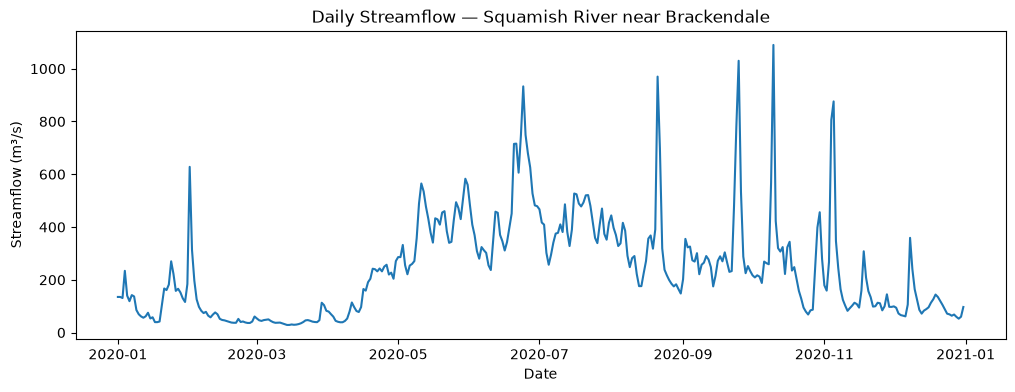

In [4]:
plt.figure(figsize=(12, 4))

plt.plot(
    df["date"],
    df["streamflow_cms"]
)

plt.title("Daily Streamflow — Squamish River near Brackendale")
plt.xlabel("Date")
plt.ylabel("Streamflow (m³/s)")
plt.show()

### Interpretation

Streamflow varies substantially throughout the year.

Flow is relatively low during late winter and early spring, before increasing strongly through late spring and early summer. Several short-duration high-flow events also occur later in the year.

The pattern suggests that both seasonality and short-term hydrological events are important.

## 3. Daily Precipitation

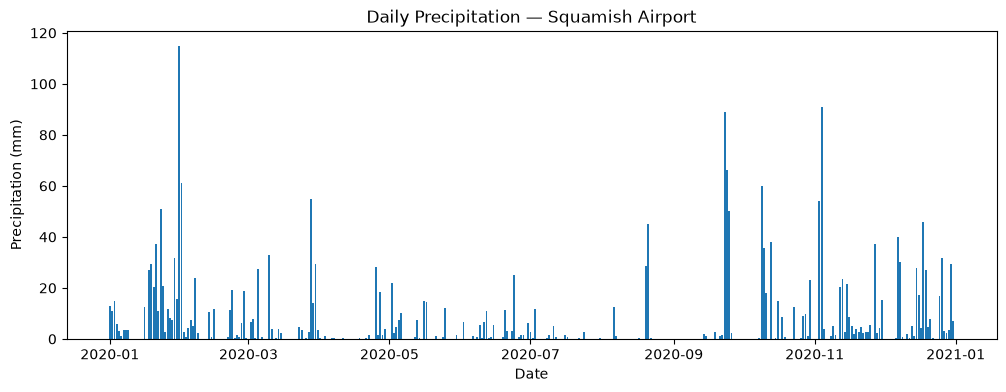

In [5]:
plt.figure(figsize=(12, 4))

plt.bar(
    df["date"],
    df["precipitation_mm"]
)

plt.title("Daily Precipitation — Squamish Airport")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.show()


### Interpretation

Precipitation is highly variable, with many low- or zero-precipitation days and several large rainfall events.

The largest precipitation event occurs during winter, while additional heavy precipitation events appear during fall.

## 4. Daily Mean Temperature


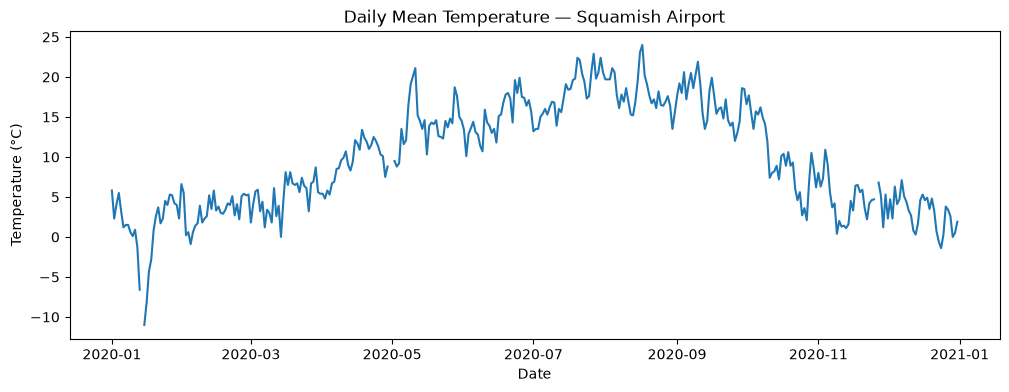

In [6]:
plt.figure(figsize=(12, 4))

plt.plot(
    df["date"],
    df["mean_temp_c"]
)

plt.title("Daily Mean Temperature — Squamish Airport")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

### Interpretation

Temperature follows a strong seasonal cycle, rising from winter into summer and declining again through fall and winter.

Because streamflow also varies seasonally, temperature may help capture seasonal hydrological processes, although this visual relationship should not be interpreted as causal.


## 5. Same-Day Precipitation vs Streamflow


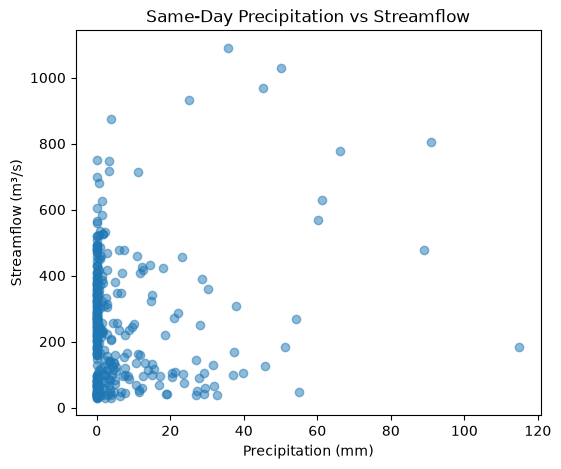

In [7]:
plot_df = df.dropna(
    subset=[
        "precipitation_mm",
        "streamflow_cms"
    ]
)

plt.figure(figsize=(6, 5))

plt.scatter(
    plot_df["precipitation_mm"],
    plot_df["streamflow_cms"],
    alpha=0.5
)

plt.title("Same-Day Precipitation vs Streamflow")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Streamflow (m³/s)")
plt.show()

In [8]:
correlation = plot_df[
    "precipitation_mm"
].corr(
    plot_df["streamflow_cms"]
)

print(
    "Correlation between precipitation and streamflow:",
    round(correlation, 3)
)

Correlation between precipitation and streamflow: 0.161


### Interpretation

The same-day precipitation versus streamflow relationship is highly scattered rather than strongly linear.

The Pearson correlation is approximately **[0.161]**, indicating that same-day precipitation alone does not explain most of the variation in streamflow.

This motivates testing lagged and accumulated precipitation features in the next stage of the project.

## 6. Monthly Streamflow Seasonality

In [9]:
df["month"] = df["date"].dt.month

monthly_flow = (
    df.groupby("month")["streamflow_cms"]
    .mean()
)

monthly_flow

month
1     123.500000
2      90.403448
3      45.606452
4     145.100000
5     402.129032
6     467.233333
7     412.451613
8     315.838710
9     322.700000
10    274.835484
11    192.450000
12    104.900000
Name: streamflow_cms, dtype: float64

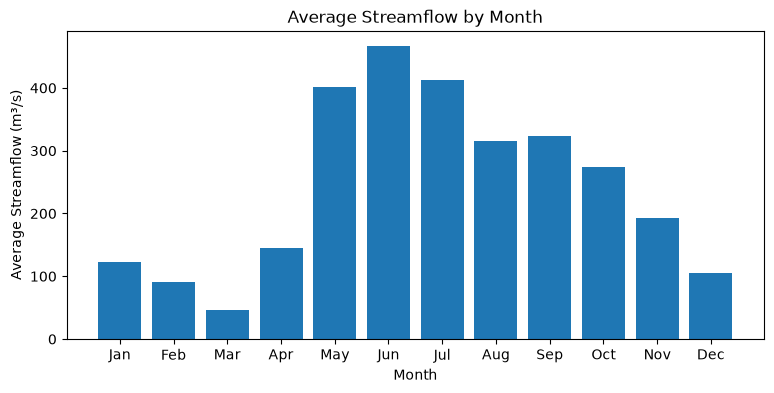

In [10]:
month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(9, 4))

plt.bar(
    month_labels,
    monthly_flow.values
)

plt.title("Average Streamflow by Month")
plt.xlabel("Month")
plt.ylabel("Average Streamflow (m³/s)")
plt.show()

### Interpretation

Average streamflow shows strong seasonality.

Mean discharge rises sharply through spring, peaks around early summer, and then generally declines later in the year.

This indicates that month or day-of-year may be useful predictive features.

In [11]:
monthly_summary = df.groupby(
    "month"
).agg(
    mean_temperature_c=(
        "mean_temp_c",
        "mean"
    ),
    total_precipitation_mm=(
        "precipitation_mm",
        "sum"
    ),
    mean_streamflow_cms=(
        "streamflow_cms",
        "mean"
    ),
    max_streamflow_cms=(
        "streamflow_cms",
        "max"
    )
)

monthly_summary.round(2)

,mean_temperature_c,total_precipitation_mm,mean_streamflow_cms,max_streamflow_cms
month,,,,
1,1.32,461.8,123.50,270.0
2,3.24,189.7,90.40,628.0
3,5.04,199.4,45.61,113.0
4,9.53,58.7,145.10,271.0
5,14.23,100.5,402.13,583.0
6,15.03,92.6,467.23,933.0
7,17.94,28.6,412.45,527.0
8,17.96,88.6,315.84,970.0
9,17.02,216.1,322.70,1030.0


## 7. Extreme Events


In [12]:
wettest_day = df.loc[
    df["precipitation_mm"].idxmax()
]

highest_flow_day = df.loc[
    df["streamflow_cms"].idxmax()
]

print("WETTEST DAY:")
print(wettest_day)

print("\nHIGHEST STREAMFLOW DAY:")
print(highest_flow_day)

WETTEST DAY:
date                2020-01-31 00:00:00
mean_temp_c                         6.6
precipitation_mm                  115.0
streamflow_cms                    184.0
month                                 1
Name: 30, dtype: object

HIGHEST STREAMFLOW DAY:
date                2020-10-10 00:00:00
mean_temp_c                        11.9
precipitation_mm                   35.7
streamflow_cms                   1090.0
month                                10
Name: 283, dtype: object


### Interpretation

The wettest day and the highest-flow day are not the same event.

The wettest day occurred on January 31, with 115 mm of precipitation and streamflow of approximately 184 m³/s.

The largest observed streamflow occurred on October 10, reaching approximately 1,090 m³/s despite only 35.7 mm of same-day precipitation.

This difference suggests that river discharge depends on more than same-day rainfall. Antecedent precipitation, previous streamflow conditions, snowmelt, watershed storage, and other hydrological processes may contribute to high-flow events.

## 8. Key Findings

1. **Streamflow is strongly seasonal.**  
   River discharge is relatively low during late winter and early spring and substantially higher through late spring and early summer.

2. **Large high-flow events occur outside the period of highest average flow.**  
   The largest daily streamflow event occurred in October, demonstrating that extreme events cannot be understood through monthly averages alone.

3. **Same-day precipitation does not fully explain streamflow.**  
   The wettest day of the year was not the highest-flow day, and the precipitation-streamflow scatterplot shows substantial variation.

4. **Temporal context is likely important.**  
   Lagged precipitation, accumulated rainfall, and previous streamflow may provide more useful predictive information than same-day precipitation alone.

5. **Temperature and seasonality may contain useful information.**  
   The strong seasonal cycle in temperature and streamflow suggests that calendar and temperature-based features may help predictive models.

## 9. Data Quality and Limitations

The analysis uses 366 daily observations from 2020.

Data quality considerations include:

- 4 missing mean-temperature observations
- 9 missing precipitation observations
- complete streamflow observations for the study period

Additional limitations include:

- Only one year of data is currently analyzed.
- One climate station may not fully represent conditions across the entire Squamish River watershed.
- Same-day correlation does not capture delayed hydrological responses.
- Important variables such as snowpack, soil moisture, elevation, watershed storage, and upstream regulation are not included.
- Correlation and feature importance should not be interpreted as evidence of causation.

This analysis is an exploratory portfolio study and not an operational flood-forecasting system.


## 10. Next Step — Feature Engineering

The exploratory analysis suggests that streamflow has both strong seasonality and temporal persistence.

The next notebook will test whether recent environmental conditions provide stronger predictive information than same-day values alone.

Features to be created include:

- Previous-day precipitation
- 3-day accumulated precipitation
- 7-day accumulated precipitation
- 3-day and 7-day mean temperature
- Previous-day streamflow
- 3-day lagged streamflow
- Previous 7-day mean streamflow
- Month
- Day of year

The modeling target will be **next-day streamflow**.